# CREDIT RISK DATASET

## 1. Importar librerías y *Credit Risk Dataset*

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

# Preprocesamiento y partición de datos
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Pipeline, preprocesamiento y búsqueda de hiperparámetros
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    make_scorer,
)

# Visualización LaTeX en notebook
from IPython.display import display, Math

import time

In [2]:
df = pd.read_csv(r"C:\Users\usuario\OneDrive\Proyectos\TFG\credit_risk_dataset.csv")

## 2. Análisis exploratorio

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [9]:
# Eliminar registros con person_age > 90 y person_emp_length == 123
print(f"Registros antes: {len(df)}")
df = df[df['person_age'] <= 90]
df = df[df['person_emp_length'] != 123]
print(f"Registros después: {len(df)}")

Registros antes: 32581
Registros después: 32573


## 3. Configuración del experimento

Se fijan en esta sección los tres elementos comunes a **todos** los experimentos del notebook: la partición de datos, los *pipelines* de preprocesamiento y el esquema de validación cruzada con las métricas de evaluación.

- **Partición train/test** (sección 3.1): 80 % / 20 %, estratificada por `loan_status` y `random_state=42`.
- **Pipelines de preprocesamiento** (sección 3.2): tres `ColumnTransformer` —uno por familia de algoritmos— que aplican `KNNImputer` (k = 5) para imputar los valores faltantes en `person_emp_length` e `loan_int_rate`, `StandardScaler` sobre las variables numéricas donde corresponde, y `OneHotEncoder` con distinta política de referencia según el modelo.
- **Esquema de validación cruzada y métricas** (sección 3.3): `StratifiedKFold` de 5 *folds* y siete métricas evaluadas simultáneamente en cada `GridSearchCV` (AUC, exactitud, tasa de error, precisión, sensibilidad, especificidad y F1-Score).

Estos tres componentes se reutilizan sin modificación en los modelos base (sección 4) y en todos los esquemas de ensamblado de las secciones 5–8 (*bagging* y *Random Forest*, *AdaBoost* y *Gradient Boosting*, *voting* y *stacking*).

### 3.1. División train/test

In [10]:
# Separar features y target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# División train/test (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean()*100:.2f}% default)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean()*100:.2f}% default)")

Train: 26058 registros (21.82% default)
Test:  6515 registros (21.81% default)


### 3.2. Pipelines de preprocesamiento

Se definen **tres** `ColumnTransformer`, uno por familia de algoritmos, para aplicar el preprocesado más adecuado a cada tipo de modelo. Estos mismos preprocesadores se reutilizan en todos los esquemas de ensamblado de las secciones 5–8.

| Preprocesador | Imputación | Escalado | OneHot `drop` | Modelos que lo usan |
|---|---|---|---|---|
| `preprocessor_lr` | KNNImputer(k=5) | **StandardScaler** | `'first'` | Regresión Logística |
| `preprocessor_knn` | KNNImputer(k=5) | **StandardScaler** | `None` | K-NN |
| `preprocessor_dt` | KNNImputer(k=5) | — | `None` | Árbol |

In [11]:
# Columnas numéricas y categóricas
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'cb_person_default_on_file']

# Pipelines numéricos
num_pipeline_scaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
num_pipeline_unscaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5))
])

# Pipelines categóricos 
cat_pipeline_lr = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_knn = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_dt = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformers por modelo
preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_lr, cat_cols)
])
preprocessor_knn = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_knn, cat_cols)
])
preprocessor_dt = ColumnTransformer([
    ('num', num_pipeline_unscaled, num_cols),
    ('cat', cat_pipeline_dt, cat_cols)
])

### 3.3. Esquema de validación cruzada y métricas

In [12]:
# Especificidad 
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Tasa de error
def error_rate_score(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

# Diccionario de métricas
scoring = {
    'AUC':           'roc_auc',
    'Exactitud':     'accuracy',
    'Tasa de error': make_scorer(error_rate_score),
    'Precisión':     'precision',
    'Sensibilidad':  'recall',
    'Especificidad': make_scorer(specificity_score),
    'F1-Score':      'f1'
}

# Estrategia de CV: 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4. Modelos de clasificación base

Se entrenan tres clasificadores base —**Regresión Logística**, **k-NN** y **Árbol de Clasificación**— empleando la partición, los preprocesadores y el esquema de validación definidos en la sección 3. Para cada modelo se realiza una búsqueda de hiperparámetros con `GridSearchCV` (`refit='AUC'`), se reportan las métricas medias en 5-fold CV de la mejor combinación y se reentrena el estimador ganador sobre todo `X_train`.

### 4.1. Regresión Logística

Se entrena una regresión logística **sin penalización** (`C=np.inf`). No hay hiperparámetros que ajustar por validación cruzada: simplemente se estiman los coeficientes con el solver 'lbfgs' y se reportan las métricas medias en 5-fold CV.

In [13]:
# Regresión Logística 
lr_pipe = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(C=np.inf, max_iter=2000, random_state=42))
])

# Hiperparámetros fijos 
lr_best_params = {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

# Validación cruzada (5 folds) con todas las métricas
lr_cv = cross_validate(lr_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
lr_metrics = {m: lr_cv[f'test_{m}'].mean() for m in scoring}

print("=== Regresión Logística ===")
print(f"Hiperparámetros: {lr_best_params}")
print("\nMétricas medias (5-fold CV):")
for m, v in lr_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Reentrenar sobre todo el conjunto de entrenamiento
lr_pipe.fit(X_train, y_train)
print("\n→ Modelo reentrenado sobre todo X_train.")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
lr_best_json = {
    'best_params': lr_best_params,
    'cv_metrics': {m: round(float(v), 4) for m, v in lr_metrics.items()}
}
with open('lr_best_params.json', 'w') as f:
    json.dump(lr_best_json, f, indent=4)
print("→ Hiperparámetros guardados en lr_best_params.json")

=== Regresión Logística ===
Hiperparámetros: {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

Métricas medias (5-fold CV):
  AUC           : 0.8711
  Exactitud     : 0.8666
  Tasa de error : 0.1334
  Precisión     : 0.7649
  Sensibilidad  : 0.5612
  Especificidad : 0.9518
  F1-Score      : 0.6474

→ Modelo reentrenado sobre todo X_train.
→ Hiperparámetros guardados en lr_best_params.json


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [14]:
# Definición lr_model, coefs e intercept para Odds Ratios
lr_prep = lr_pipe.named_steps['preprocessor']
ohe_lr  = lr_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names_lr = list(ohe_lr.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_feature_names_lr

lr_model  = lr_pipe.named_steps['classifier']
coefs     = lr_model.coef_[0]
intercept = lr_model.intercept_[0]

In [15]:
# Tabla de los Odds Ratios
or_df = pd.DataFrame({
    'Variable':         feature_names,
    'Coeficiente (b)':  np.round(coefs, 4),
    'Odds Ratio (e^b)': np.round(np.exp(coefs), 4)
}).sort_values('Odds Ratio (e^b)', ascending=False).reset_index(drop=True)
or_df.index += 1

print(f'Intercepto (b₀): {intercept:.4f}\n')
or_df

Intercepto (b₀): -2.2694



,Variable,Coeficiente (b),Odds Ratio (e^b)
1,loan_grade_G,6.3114,550.8068
2,loan_grade_F,3.1679,23.7571
3,loan_grade_E,2.7244,15.2467
4,loan_grade_D,2.5062,12.2578
5,loan_percent_income,1.4755,4.3734
6,person_home_ownership_RENT,0.8373,2.3101
7,loan_grade_C,0.4087,1.5048
8,person_home_ownership_OTHER,0.2750,1.3165
9,loan_int_rate,0.2110,1.2350
10,loan_grade_B,0.1990,1.2202


### 4.2. K-NN

Búsqueda de la mejor combinación de hiperparámetros entre las 48 posibles:
- `n_neighbors` ∈ {5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401}
- `weights` ∈ {'uniform', 'distance'}
- `metric` ∈ {'euclidean', 'manhattan'}

In [16]:
# K-NN
knn_pipe = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier())
])

# Se prueba con 48 combinaciones de hiperparámetros (12 × 2 × 2)
knn_params = {
    'classifier__n_neighbors': [5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipe, knn_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=2
)
knn_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
knn_best_idx = knn_grid.best_index_
knn_best_params = {k.replace('classifier__', ''): v for k, v in knn_grid.best_params_.items()}
knn_metrics = {m: knn_grid.cv_results_[f'mean_test_{m}'][knn_best_idx] for m in scoring}

print("=== K-NN ===")
print(f"Mejores hiperparámetros: {knn_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in knn_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
knn_best_json = {
    'best_params': knn_best_params,
    'cv_metrics': {m: round(float(v), 4) for m, v in knn_metrics.items()}
}
with open('knn_best_params.json', 'w') as f:
    json.dump(knn_best_json, f, indent=4)
print("→ Hiperparámetros guardados en knn_best_params.json")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
=== K-NN ===
Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 37, 'weights': 'distance'}

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9003
  Exactitud     : 0.8962
  Tasa de error : 0.1038
  Precisión     : 0.9207
  Sensibilidad  : 0.5733
  Especificidad : 0.9863
  F1-Score      : 0.7066

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en knn_best_params.json


#### Curva AUC frente a $k$

Fijada la mejor combinación de hiperparámetros (`weights='distance'`, `metric='manhattan'`), se representa el AUC medio en validación cruzada en función del número de vecinos $k$. Esta curva permite visualizar empíricamente el **dilema sesgo-varianza** discutido en la Sección 2.4: valores muy pequeños de $k$ generan modelos de alta varianza (sobreajustan al ruido del *train*), mientras que valores muy grandes incrementan el sesgo (suavizan en exceso la frontera de decisión). El óptimo se sitúa en el valor de $k$ que minimiza el error en CV.

Curva AUC vs k  (weights='distance', metric='manhattan')

  k  mean_test_AUC
  5         0.8723
 11         0.8891
 21         0.8976
 25         0.8984
 29         0.8991
 32         0.9000
 35         0.9002
 37         0.9003
 71         0.8992
151         0.8957
251         0.8931
401         0.8892


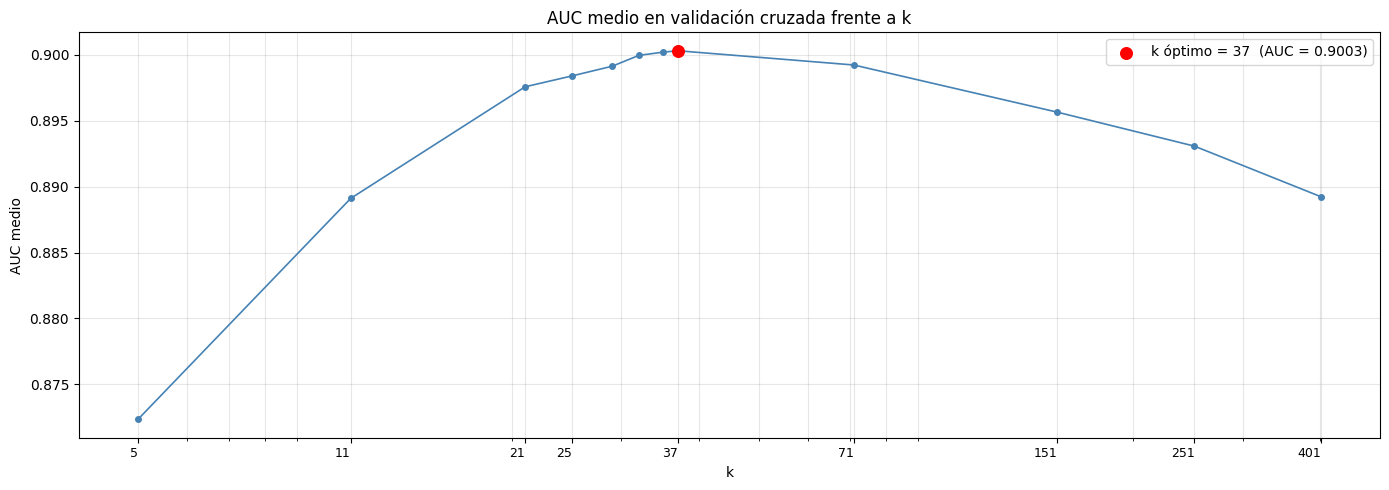

In [17]:
# Curva AUC vs k con la mejor combinación de weights y metric
best_w = knn_best_params['weights']
best_m = knn_best_params['metric']

knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
mask = (
    (knn_cv_df['param_classifier__weights'] == best_w) &
    (knn_cv_df['param_classifier__metric']  == best_m)
)
curve_df = (
    knn_cv_df.loc[mask]
        .assign(k=lambda d: d['param_classifier__n_neighbors'].astype(int))
        [['k', 'mean_test_AUC']]
        .sort_values('k')
        .reset_index(drop=True)
)

print(f"Curva AUC vs k  (weights='{best_w}', metric='{best_m}')\n")
print(curve_df.round(4).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(curve_df['k'], curve_df['mean_test_AUC'],
        'o-', color='steelblue', markersize=4, linewidth=1.2)

best_k   = knn_best_params['n_neighbors']
best_auc = curve_df.loc[curve_df['k'] == best_k, 'mean_test_AUC'].values[0]
ax.scatter([best_k], [best_auc], color='red', zorder=5, s=70,
           label=f'k óptimo = {best_k}  (AUC = {best_auc:.4f})')

ax.set_xscale('log')

# Ticks equiespaciados en escala logarítmica (~12), snapping al k real más cercano
tick_targets = np.geomspace(curve_df['k'].min(), curve_df['k'].max(), 12)
tick_vals = [curve_df['k'].iloc[(curve_df['k'] - t).abs().argmin()] for t in tick_targets]
tick_vals = sorted(set(tick_vals))
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_vals, ha='right', fontsize=9)

ax.set_xlabel('k')
ax.set_ylabel('AUC medio')
ax.set_title('AUC medio en validación cruzada frente a k')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.savefig('Fotos/k-NN - AUC vs k.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3. Árbol de Clasificación

Búsqueda de la mejor combinación de hiperparámetros entre las 448 posibles:
- `criterion` ∈ {'gini', 'entropy'}
- `max_depth` ∈ {3, 5, 7, 10, 15, 20, None}
- `min_samples_split` ∈ {2, 5, 10, 20}
- `min_samples_leaf` ∈ {1, 5, 10, 20}
- `classifier__class_weight` ∈ {None, 'balanced'}

In [18]:
# Árbol de Clasificación 
dt_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Se prueba con 448 combinaciones de hiperparámetros
dt_params = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_depth': [3, 5, 7, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10, 20]
}

dt_grid = GridSearchCV(
    dt_pipe, dt_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=2
)
dt_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
dt_best_idx = dt_grid.best_index_
dt_best_params = {k.replace('classifier__', ''): v for k, v in dt_grid.best_params_.items()}
dt_metrics = {m: dt_grid.cv_results_[f'mean_test_{m}'][dt_best_idx] for m in scoring}

print("=== Árbol de Clasificación ===")
print(f"Mejores hiperparámetros: {dt_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in dt_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
dt_best_json = {
    'best_params': dt_best_params,
    'cv_metrics': {m: round(float(v), 4) for m, v in dt_metrics.items()}
}
with open('dt_best_params.json', 'w') as f:
    json.dump(dt_best_json, f, indent=4)
print("→ Hiperparámetros guardados en dt_best_params.json")

Fitting 5 folds for each of 448 candidates, totalling 2240 fits
=== Árbol de Clasificación ===
Mejores hiperparámetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9168
  Exactitud     : 0.8918
  Tasa de error : 0.1082
  Precisión     : 0.7442
  Sensibilidad  : 0.7687
  Especificidad : 0.9262
  F1-Score      : 0.7562

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en dt_best_params.json


#### Visualización del árbol de clasificación

Se representa el árbol entrenado limitado a profundidad $2$ para que sea legible. 

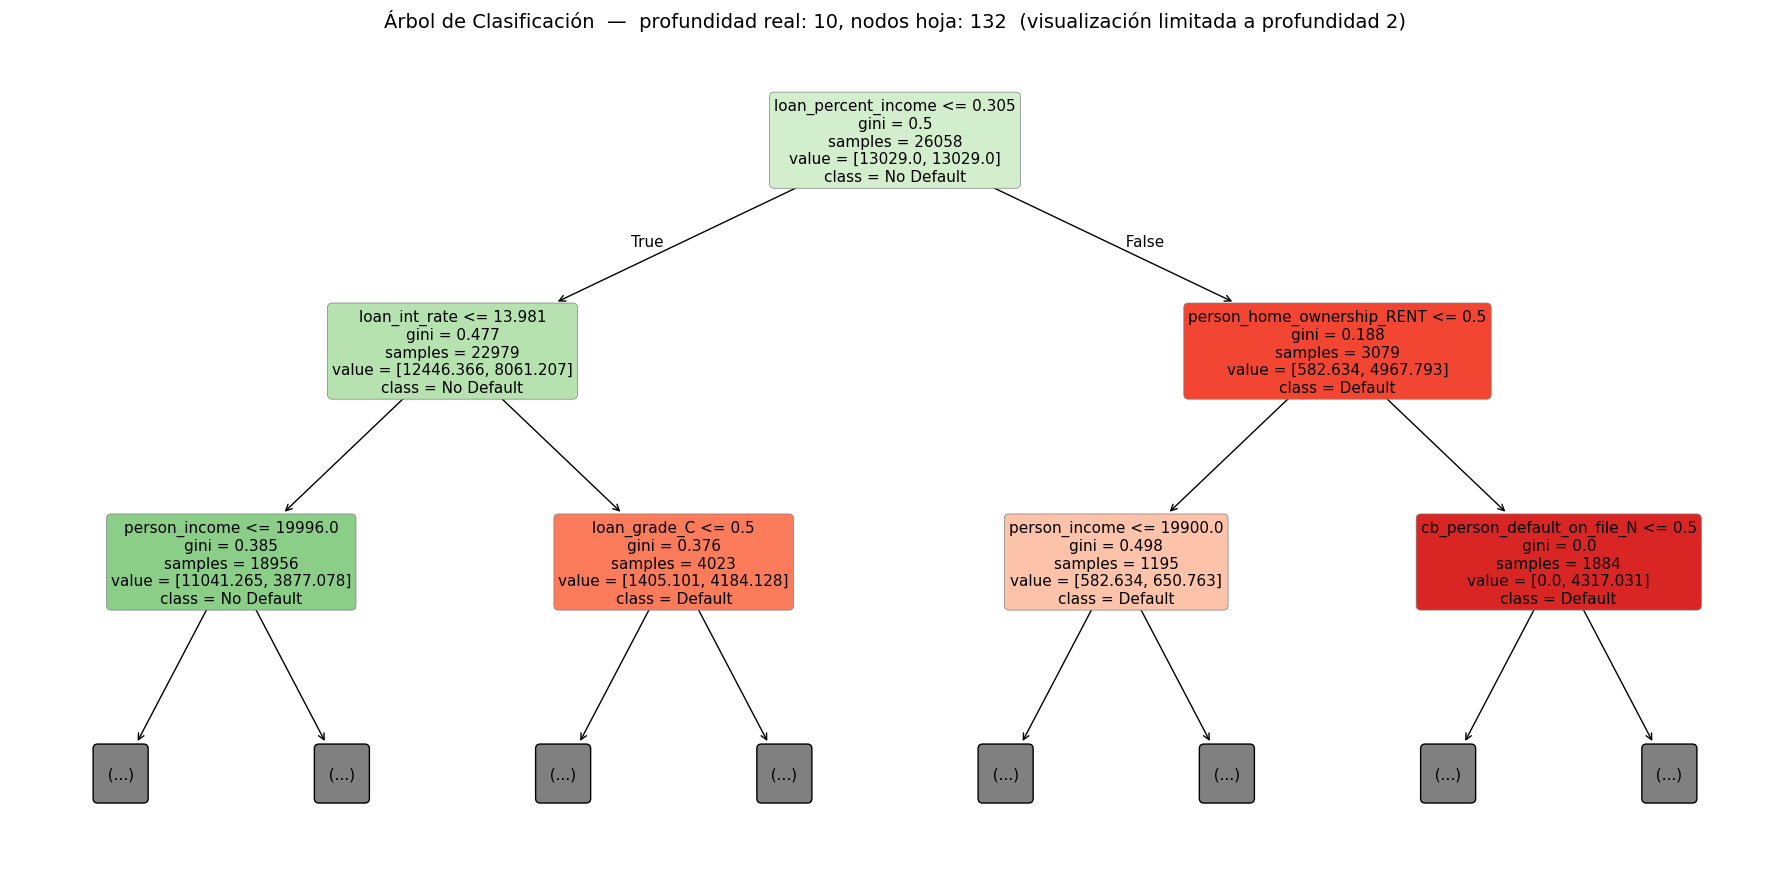

In [19]:
# Pipeline reentrenado y nombres de las variables predictoras tras el preprocesado
dt_pipe_fit = dt_grid.best_estimator_
dt_model    = dt_pipe_fit.named_steps['classifier']
dt_prep     = dt_pipe_fit.named_steps['preprocessor']

ohe_dt            = dt_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe_dt.get_feature_names_out(cat_cols))
feature_names_dt  = num_cols + cat_feature_names

# Gráfico del árbol limitado a profundidad 2
fig, ax = plt.subplots(figsize=(18, 9))
artists = plot_tree(
    dt_model,
    feature_names=feature_names_dt,
    class_names=['No Default', 'Default'],
    filled=True, rounded=True, fontsize=11,
    max_depth=2, ax=ax
)

# Recorrido DFS en preorden hasta profundidad 2 (mismo orden que dibuja plot_tree)
tree_ = dt_model.tree_
orden = []
def _dfs(n, d, max_d=2):
    orden.append(n)
    if d >= max_d or tree_.children_left[n] == tree_.children_right[n]:
        return
    _dfs(tree_.children_left[n],  d + 1, max_d)
    _dfs(tree_.children_right[n], d + 1, max_d)
_dfs(0, 0)

# Recoloreado: verde si la clase mayoritaria es Y=0 (No Default), rojo si es Y=1 (Default),
# con intensidad proporcional a la pureza del nodo.
real_artists = [a for a in artists if 'samples' in a.get_text()]

for ann, n in zip(real_artists, orden):
    valores     = tree_.value[n][0]
    clase_mayor = int(valores.argmax())
    pureza      = valores.max() / valores.sum()
    intensidad  = 0.2 + (pureza - 0.5)

    cmap  = plt.cm.Reds if clase_mayor == 1 else plt.cm.Greens
    color = cmap(intensidad)

    ann.set_bbox(dict(boxstyle='round,pad=0.3',
                      facecolor=color, edgecolor='gray', linewidth=0.5))

ax.set_title(
    f'Árbol de Clasificación  —  profundidad real: {dt_model.get_depth()}, '
    f'nodos hoja: {dt_model.get_n_leaves()}  (visualización limitada a profundidad 2)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('Fotos/arbol_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

#### Importancia de las variables predictoras

A partir del árbol se cuantifica la importancia que se asigna a cada variable predictora siguiendo los siguientes cuatro pasos:

**1. Reducción ponderada de impureza de un nodo.** Para cada nodo interno $t$ con hijos izquierdo $t_L$ y derecho $t_R$, se mide cuánto mejora la pureza global del árbol gracias a esa partición:

$$\Delta i(t) = \dfrac{N_t}{N}\left[\,i(t) - \dfrac{N_{t_L}}{N_t}\,i(t_L) - \dfrac{N_{t_R}}{N_t}\,i(t_R)\right]$$

donde $i(\cdot)$ es la impureza (Gini o entropía según el criterio elegido), $N$ es el número total de muestras de entrenamiento y $N_t$, $N_{t_L}$, $N_{t_R}$ son las muestras que caen en cada nodo.

**2. Importancia por variable.** Para cada variable predictora $X_j$, su importancia bruta se obtiene sumando las reducciones de impureza de todos los nodos internos que parten por $X_j$:

$$\widetilde{\mathrm{Imp}}(X_j) = \sum_{\substack{t \in \mathcal{T}_{\text{int}} \\ v(t) = X_j}} \Delta i(t)$$

donde $\mathcal{T}_{\text{int}}$ es el conjunto de nodos internos y $v(t)$ la variable por la que se parte en el nodo $t$. Las variables que no participan en ninguna partición tienen importancia bruta $0$.

**3. Importancia normalizada por variable.** Las importancias brutas se normalizan dividiendo por su suma para que formen una distribución (sumen $1$):

$$\mathrm{Imp}(X_j) = \dfrac{\widetilde{\mathrm{Imp}}(X_j)}{\sum_{k=1}^{p} \widetilde{\mathrm{Imp}}(X_k)}$$

Esta cantidad es precisamente el atributo `feature_importances_` que devuelve `scikit-learn`.

**4. Importancia por variable original.** Como las variables categóricas se han codificado mediante *one-hot encoding* en varias *dummies*, la importancia del paso anterior se calcula sobre las variables ya codificadas. Para una lectura más interpretable, se suman las contribuciones de todas las *dummies* de una misma variable categórica:

$$\mathrm{Imp}(X) = \sum_{c \in \mathcal{C}(X)} \mathrm{Imp}(X_c)$$

donde $\mathcal{C}(X)$ es el conjunto de categorías de $X$.

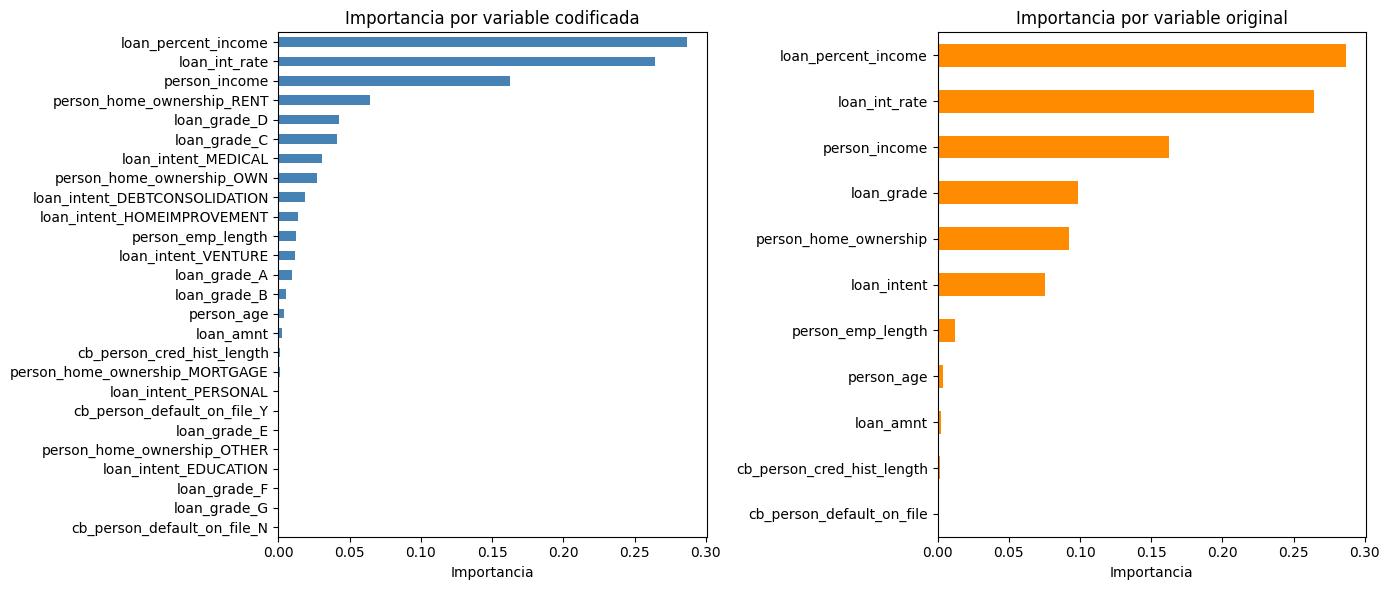

,Variable,Importancia
1,loan_percent_income,0.2866
2,loan_int_rate,0.2642
3,person_income,0.1625
4,person_home_ownership_RENT,0.0642
5,loan_grade_D,0.0423
6,loan_grade_C,0.0414
7,loan_intent_MEDICAL,0.0307
8,person_home_ownership_OWN,0.0269
9,loan_intent_DEBTCONSOLIDATION,0.0189
10,loan_intent_HOMEIMPROVEMENT,0.0134


In [20]:
# Importancia de cada variable predictora codificada
imp_df = pd.DataFrame({
    'Variable':    feature_names_dt,
    'Importancia': dt_model.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
imp_df.index += 1

# Agregación por variable original (suma de las dummies de cada categórica)
def variable_origen(nombre):
    for c in cat_cols:
        if nombre.startswith(c + '_'):
            return c
    return nombre

imp_agg = (
    imp_df.assign(**{'Variable original': imp_df['Variable'].map(variable_origen)})
          .groupby('Variable original', as_index=False)['Importancia'].sum()
          .sort_values('Importancia', ascending=False)
          .reset_index(drop=True)
)
imp_agg.index += 1
imp_agg['Importancia'] = imp_agg['Importancia'].round(4)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_df.plot.barh(x='Variable', y='Importancia', ax=axes[0],
                 legend=False, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Importancia por variable codificada')
axes[0].set_xlabel('Importancia'); axes[0].set_ylabel('')

imp_agg.plot.barh(x='Variable original', y='Importancia', ax=axes[1],
                  legend=False, color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Importancia por variable original')
axes[1].set_xlabel('Importancia'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('Fotos/importancia_variables_dt.png', dpi=150, bbox_inches='tight')
plt.show()

imp_df  # Tabla con la importancia por variable codificada

### 4.4. Resumen comparativo

In [21]:
# Tabla comparativa con las métricas medias en 5-fold CV
summary = pd.DataFrame({
    'Regresión Logística':   lr_metrics,
    'K-NN':                  knn_metrics,
    'Árbol de Clasificación': dt_metrics
}).T.round(4)

summary

,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Regresión Logística,0.8711,0.8666,0.1334,0.7649,0.5612,0.9518,0.6474
K-NN,0.9003,0.8962,0.1038,0.9207,0.5733,0.9863,0.7066
Árbol de Clasificación,0.9168,0.8918,0.1082,0.7442,0.7687,0.9262,0.7562


## 5. Bagging y Random Forest

### 5.1. Bagging con k-NN como estimador base

El objetivo de esta subsección es doble: 
1. Ilustrar cómo el *bagging* reduce el error de forma más pronunciada cuando el estimador base tiene **alta varianza** (k pequeño, el k-NN sobreajusta), y cómo esta ganancia se diluye conforme el modelo base se estabiliza (k grande, baja varianza).
2. Ver si algún bagging con k-NN como modelo base supera al k-NN óptimo de la sección 4.

Se fijan `weights='distance'` y `metric='manhattan'` en sus valores óptimos y se combinan **12 combinaciones** de hiperparámetros: `n_neighbors` ∈ {5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401}

In [22]:
k_values = [5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401]

bagging_knn_records = []

t0 = time.perf_counter()
for k in k_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor_knn),
        ('classifier', BaggingClassifier(
            estimator=KNeighborsClassifier(
                n_neighbors=k, weights='distance', metric='manhattan'
            ),
            n_estimators=50,
            bootstrap=True,
            max_samples=1.0,
            random_state=42,
            n_jobs=-1                # paraleliza los 200 estimadores
        ))
    ])

    cv_out = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=1   # ya paralelizado dentro de Bagging
    )

    record = {'n_estimators': 50, 'n_neighbors': k,
              **{m: float(np.mean(cv_out[f'test_{m}'])) for m in scoring}}
    bagging_knn_records.append(record)
    print(f"  k = {k:>4}   AUC = {record['AUC']:.6f}")
t1 = time.perf_counter()

bagging_knn_results = pd.DataFrame(bagging_knn_records)

# Mejor combinación según AUC medio
best_idx = bagging_knn_results['AUC'].idxmax()
bagging_knn_best_params_val = {
    'n_estimators': int(bagging_knn_results.loc[best_idx, 'n_estimators']),
    'n_neighbors':  int(bagging_knn_results.loc[best_idx, 'n_neighbors'])
}
bagging_knn_metrics = {m: float(bagging_knn_results.loc[best_idx, m]) for m in scoring}

print("\n=== Bagging k-NN ===")
print(f"Mejores hiperparámetros: {bagging_knn_best_params_val}")
print(f"→ Tiempo total: {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in bagging_knn_metrics.items():
    print(f"  {m:<14}: {v:.6f}")

print("\nRendimiento de todas las combinaciones:")
print(bagging_knn_results.round(6).to_string(index=False))

# Guardar JSON
with open('bagging_knn_best_params.json', 'w') as f:
    json.dump({'best_params': bagging_knn_best_params_val,
               'cv_metrics':  {m: round(v, 6) for m, v in bagging_knn_metrics.items()}},
              f, indent=4)

with open('bagging_knn_all_results.json', 'w') as f:
    json.dump(bagging_knn_results.round(6).to_dict(orient='records'), f, indent=4)

print("\n→ Resultados guardados en bagging_knn_best_params.json y bagging_knn_all_results.json")

  k =    5   AUC = 0.885681
  k =   11   AUC = 0.894454
  k =   21   AUC = 0.899174
  k =   25   AUC = 0.899890
  k =   29   AUC = 0.900243
  k =   32   AUC = 0.900389
  k =   35   AUC = 0.900448
  k =   37   AUC = 0.900361
  k =   71   AUC = 0.899230
  k =  151   AUC = 0.895757
  k =  251   AUC = 0.892967
  k =  401   AUC = 0.889086

=== Bagging k-NN ===
Mejores hiperparámetros: {'n_estimators': 50, 'n_neighbors': 35}
→ Tiempo total: 1629.7 s

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.900448
  Exactitud     : 0.896424
  Tasa de error : 0.103576
  Precisión     : 0.920955
  Sensibilidad  : 0.574569
  Especificidad : 0.986256
  F1-Score      : 0.707604

Rendimiento de todas las combinaciones:
 n_estimators  n_neighbors      AUC  Exactitud  Tasa de error  Precisión  Sensibilidad  Especificidad  F1-Score
           50            5 0.885681   0.897114       0.102886   0.865684      0.625571       0.972904  0.726266
           50           11 0.894454   0.901

#### Curva AUC frente a k

La gráfica siguiente de AUC frente a k muestra empíricamente cómo el beneficio del ensamblado decrece con k, en línea con la predicción de Breiman de que el *bagging* solo es útil cuando el estimador base es inestable.

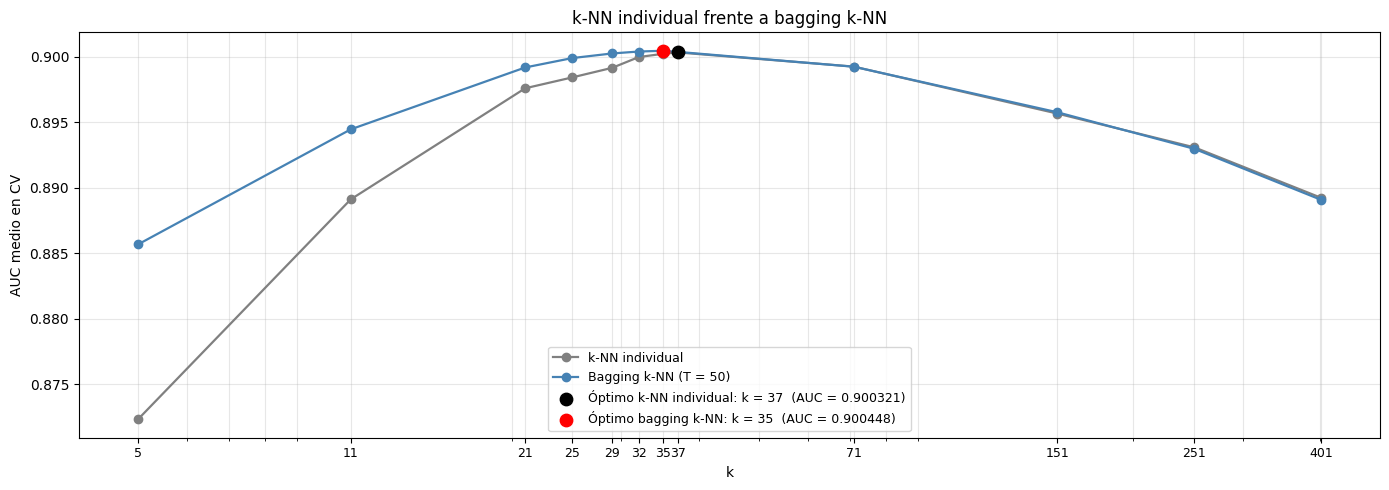

In [40]:
# Cargar referencia del k-NN sin bagging si no está en memoria
if 'knn_metrics' not in globals() or 'knn_best_params' not in globals():
    with open('knn_best_params.json', 'r') as f:
        _knn_json = json.load(f)
    knn_best_params = _knn_json['best_params']
    knn_metrics     = _knn_json['cv_metrics']

# Curva AUC del k-NN individual sobre los mismos 12 valores de k
best_w = knn_best_params['weights']
best_m = knn_best_params['metric']

knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
mask = (
    (knn_cv_df['param_classifier__weights'] == best_w) &
    (knn_cv_df['param_classifier__metric']  == best_m)
)
knn_curve = (
    knn_cv_df.loc[mask]
        .assign(n_neighbors=lambda d: d['param_classifier__n_neighbors'].astype(int))
        [['n_neighbors', 'mean_test_AUC']]
        .rename(columns={'mean_test_AUC': 'AUC'})
        .sort_values('n_neighbors')
        .reset_index(drop=True)
)

# Curva AUC del bagging k-NN
bag_curve = bagging_knn_results.sort_values('n_neighbors').reset_index(drop=True)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))

# k-NN individual
ax.plot(knn_curve['n_neighbors'], knn_curve['AUC'],
        'o-', color='gray', markersize=6, linewidth=1.6,
        label='k-NN individual')

# Bagging k-NN
ax.plot(bag_curve['n_neighbors'], bag_curve['AUC'],
        'o-', color='steelblue', markersize=6, linewidth=1.6,
        label='Bagging k-NN (T = 50)')

# Óptimo k-NN individual
best_k_knn   = knn_best_params['n_neighbors']
best_auc_knn = knn_curve.loc[knn_curve['n_neighbors'] == best_k_knn, 'AUC'].values[0]
ax.scatter([best_k_knn], [best_auc_knn], color='black', zorder=6, s=80,
           label=f'Óptimo k-NN individual: k = {best_k_knn}  (AUC = {best_auc_knn:.6f})')

# Óptimo bagging k-NN
best_k_bag   = bagging_knn_best_params_val['n_neighbors']
best_auc_bag = bagging_knn_metrics['AUC']
ax.scatter([best_k_bag], [best_auc_bag], color='red', zorder=6, s=80,
           label=f'Óptimo bagging k-NN: k = {best_k_bag}  (AUC = {best_auc_bag:.6f})')

ax.set_xscale('log')
ax.set_xticks(k_values)
ax.set_xticklabels(k_values, fontsize=9)
ax.set_xlabel('k')
ax.set_ylabel('AUC medio en CV')
ax.set_title('k-NN individual frente a bagging k-NN')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9, loc='lower center')
plt.tight_layout()
plt.savefig('Fotos/bagging_knn_vs_knn_AUC_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2. Bagging con árbol de clasificación como estimador base

Se van compara *bagging* con árboles de decisión en su versión original (con `bootstrap=TRUE`) y en una versión alternativa con `bootstrap=FALSE` para ilustrar como este bootstrap mejora la capacidad predictiva del modelo al hacer que varíe el conjunto de entrenamiento. 

In [24]:
# Bagging con árbol de clasificación sin podar como estimador base
bagging_tree_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=None,
            min_samples_leaf=1,
            min_samples_split=2,
            class_weight='balanced',
            random_state=42
        ),
        random_state=42
    ))
])

bagging_tree_params = {
    'classifier__n_estimators': [500],
    'classifier__bootstrap':    [True, False],
}

t0 = time.perf_counter()
bagging_tree_grid = GridSearchCV(
    bagging_tree_pipe, bagging_tree_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=-1, verbose=2
)
bagging_tree_grid.fit(X_train, y_train)
t1 = time.perf_counter()

# Mejor combinación global
bt_cv_df = pd.DataFrame(bagging_tree_grid.cv_results_)
bagging_tree_best_idx = bagging_tree_grid.best_index_
bagging_tree_best_params_val = {k.replace('classifier__', ''): v
                                 for k, v in bagging_tree_grid.best_params_.items()}
bagging_tree_metrics = {m: float(bt_cv_df.loc[bagging_tree_best_idx, f'mean_test_{m}'])
                        for m in scoring}

print("=== Bagging Árbol de Clasificación ===")
print(f"Mejores hiperparámetros (global): {bagging_tree_best_params_val}")
print(f"\n→ Tiempo de entrenamiento (GridSearchCV): {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) — mejor configuración global:")
for m, v in bagging_tree_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Mejor configuración con bootstrap=True
mask_bt = bt_cv_df['param_classifier__bootstrap'] == True
bt_idx = bt_cv_df.loc[mask_bt, 'mean_test_AUC'].idxmax()
bagging_tree_bootstrap_params_val = {
    'n_estimators': int(bt_cv_df.loc[bt_idx, 'param_classifier__n_estimators']),
    'bootstrap':    True
}
bagging_tree_bootstrap_metrics = {m: float(bt_cv_df.loc[bt_idx, f'mean_test_{m}']) for m in scoring}

print("\nMétricas medias (5-fold CV) — mejor configuración bootstrap=True:")
for m, v in bagging_tree_bootstrap_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Mejor configuración con bootstrap=False (pasting)
mask_pt = bt_cv_df['param_classifier__bootstrap'] == False
pt_idx = bt_cv_df.loc[mask_pt, 'mean_test_AUC'].idxmax()
bagging_tree_pasting_params_val = {
    'n_estimators': int(bt_cv_df.loc[pt_idx, 'param_classifier__n_estimators']),
    'bootstrap':    False
}
bagging_tree_pasting_metrics = {m: float(bt_cv_df.loc[pt_idx, f'mean_test_{m}']) for m in scoring}

print("\nMétricas medias (5-fold CV) — mejor configuración bootstrap=False (pasting):")
for m, v in bagging_tree_pasting_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar JSONs (estructura común: best_params + cv_metrics)
json_saves = [
    ('bagging_tree_best_params.json',          bagging_tree_best_params_val,       bagging_tree_metrics),
    ('bagging_tree_bootstrap_best_params.json', bagging_tree_bootstrap_params_val, bagging_tree_bootstrap_metrics),
    ('bagging_tree_pasting_best_params.json',   bagging_tree_pasting_params_val,   bagging_tree_pasting_metrics),
]
for fname, params, metrics in json_saves:
    data = {
        'best_params': params,
        'cv_metrics':  {m: round(v, 4) for m, v in metrics.items()}
    }
    with open(fname, 'w') as f:
        json.dump(data, f, indent=4)
print("→ JSONs guardados: bagging_tree_best_params.json, bagging_tree_bootstrap_best_params.json, bagging_tree_pasting_best_params.json")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
=== Bagging Árbol de Clasificación ===
Mejores hiperparámetros (global): {'bootstrap': True, 'n_estimators': 500}

→ Tiempo de entrenamiento (GridSearchCV): 129.9 s

Métricas medias (5-fold CV) — mejor configuración global:
  AUC           : 0.9369
  Exactitud     : 0.9325
  Tasa de error : 0.0675
  Precisión     : 0.9661
  Sensibilidad  : 0.7160
  Especificidad : 0.9930
  F1-Score      : 0.8224

Métricas medias (5-fold CV) — mejor configuración bootstrap=True:
  AUC           : 0.9369
  Exactitud     : 0.9325
  Tasa de error : 0.0675
  Precisión     : 0.9661
  Sensibilidad  : 0.7160
  Especificidad : 0.9930
  F1-Score      : 0.8224

Métricas medias (5-fold CV) — mejor configuración bootstrap=False (pasting):
  AUC           : 0.8561
  Exactitud     : 0.8911
  Tasa de error : 0.1089
  Precisión     : 0.7480
  Sensibilidad  : 0.7555
  Especificidad : 0.9290
  F1-Score      : 0.7518

→ Modelo reentrenado sobre todo X_train (refi

### 5.3. Random Forest

Se lleva a cabo `GridSearchCV` con  `max_features` ∈ {`'log2'`, `'sqrt'`, 0.3, 0.5, 0.7}.

In [25]:
# Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', RandomForestClassifier(
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2,
        bootstrap=True,
        class_weight='balanced',
        random_state=42
    ))
])

rf_params = {
    'classifier__n_estimators': [500],
    'classifier__max_features': ['log2', 'sqrt', 0.3, 0.5, 0.7, 1]
}

t0 = time.perf_counter()
rf_grid = GridSearchCV(
    rf_pipe, rf_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=-1, verbose=2
)
rf_grid.fit(X_train, y_train)
t1 = time.perf_counter()

rf_best_idx = rf_grid.best_index_
rf_best_params_val = {k.replace('classifier__', ''): v for k, v in rf_grid.best_params_.items()}
rf_metrics = {m: float(rf_grid.cv_results_[f'mean_test_{m}'][rf_best_idx]) for m in scoring}

print("=== Random Forest ===")
print(f"Mejores hiperparámetros: {rf_best_params_val}")
print(f"\n→ Tiempo de entrenamiento (GridSearchCV): {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in rf_metrics.items():
    print(f"  {m:<14}: {v:.4f}")
print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
rf_best_json = {
    'best_params': rf_best_params_val,
    'cv_metrics':  {m: round(v, 4) for m, v in rf_metrics.items()}
}
with open('rf_best_params.json', 'w') as f:
    json.dump(rf_best_json, f, indent=4)
print("→ Hiperparámetros guardados en rf_best_params.json")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
=== Random Forest ===
Mejores hiperparámetros: {'max_features': 0.7, 'n_estimators': 500}

→ Tiempo de entrenamiento (GridSearchCV): 106.6 s

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9384
  Exactitud     : 0.9336
  Tasa de error : 0.0664
  Precisión     : 0.9727
  Sensibilidad  : 0.7160
  Especificidad : 0.9944
  F1-Score      : 0.8248

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en rf_best_params.json


### 5.4. Comparativa de modelos de bagging

Se recogen las métricas medias en 5-fold CV de tres de las cuatro configuraciones evaluadas en esta sección: el *bagging* de árboles con *bootstrap* y sin él (lo que permite aislar la aportación del remuestreo con reemplazo) y el *Random Forest*.

In [26]:
# Tabla comparativa de los 3 modelos ensamblados (métricas medias en 5-fold CV)
ensemble_summary = pd.DataFrame({
    'Bagging Árbol — Bootstrap': bagging_tree_bootstrap_metrics,
    'Bagging Árbol — Sin Bootstrap':   bagging_tree_pasting_metrics,
    'Random Forest':             rf_metrics
}).T.round(4)

ensemble_summary

,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Bagging Árbol — Bootstrap,0.9369,0.9325,0.0675,0.9661,0.7160,0.9930,0.8224
Bagging Árbol — Sin Bootstrap,0.8561,0.8911,0.1089,0.7480,0.7555,0.9290,0.7518
Random Forest,0.9384,0.9336,0.0664,0.9727,0.7160,0.9944,0.8248


## 6. AdaBoost y Gradient Boosting

Se estudian dos técnicas de *boosting*: **AdaBoost** y **Gradient Boosting**. Se plantean tres experimentos: 
1. Comparar AdaBoost con k-NN frente al k-NN individual y al bagging k-NN sobre los mismos 12 valores de $k$.
2. Analizar si AdaBoost sobreajusta al aumentar $T$.
3. Comparativa final entre el árbol individual, AdaBoost y Gradient Boosting.

### 6.1. Experimento 1: AdaBoost con k-NN frente a bagging k-NN

Se fijan `weights='distance'` y `metric='manhattan'` y se varía $k \in \{5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401\}$ con $T = 50$ estimadores. Como `KNeighborsClassifier` no admite `sample_weight`, se implementa un wrapper `WeightedKNN` que sustituye la ponderación directa por remuestreo bootstrap ponderado (equivalente en esperanza). 

In [28]:
k_values = [5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401]

# Wrapper para que AdaBoost pueda usar k-NN mediante remuestreo bootstrap ponderado.
# KNeighborsClassifier no implementa sample_weight en fit(); este wrapper
# aproxima la ponderación generando una submuestra con reemplazo proporcional
# a los pesos de AdaBoost (equivalente en esperanza a la ponderación directa).
class WeightedKNN(KNeighborsClassifier):
    def fit(self, X, y, sample_weight=None):
        if sample_weight is not None:
            n = len(y)
            probs = np.asarray(sample_weight, dtype=float)
            probs /= probs.sum()
            idx = np.random.choice(n, size=n, replace=True, p=probs)
            X = np.asarray(X)[idx]
            y = np.asarray(y)[idx]
        return super().fit(X, y)

adaboost_knn_records = []

t0 = time.perf_counter()
for k in k_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor_knn),
        ('classifier', AdaBoostClassifier(
            estimator=WeightedKNN(n_neighbors=k, weights='distance', metric='manhattan'),
            n_estimators=50,
            random_state=42
        ))
    ])
    cv_out = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    record = {'n_neighbors': k,
              **{m: float(np.mean(cv_out[f'test_{m}'])) for m in scoring}}
    adaboost_knn_records.append(record)
    print(f"  k = {k:>4}   AUC = {record['AUC']:.6f}")
t1 = time.perf_counter()

adaboost_knn_results = pd.DataFrame(adaboost_knn_records)

best_idx_knn_ada = adaboost_knn_results['AUC'].idxmax()
adaboost_knn_best_params_val = {
    'n_estimators': 50,
    'n_neighbors':  int(adaboost_knn_results.loc[best_idx_knn_ada, 'n_neighbors']),
    'weights':      'distance',
    'metric':       'manhattan',
}
adaboost_knn_metrics = {m: float(adaboost_knn_results.loc[best_idx_knn_ada, m]) for m in scoring}

print(f"\n=== AdaBoost k-NN ===")
print(f"Mejores hiperparámetros: {adaboost_knn_best_params_val}")
print(f"→ Tiempo total: {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in adaboost_knn_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

with open('adaboost_knn_best_params.json', 'w') as f:
    json.dump({'best_params': adaboost_knn_best_params_val,
               'cv_metrics':  {m: round(v, 4) for m, v in adaboost_knn_metrics.items()}},
              f, indent=4)
print("→ Hiperparámetros guardados en adaboost_knn_best_params.json")

  k =    5   AUC = 0.864391
  k =   11   AUC = 0.878650
  k =   21   AUC = 0.887150
  k =   25   AUC = 0.887832
  k =   29   AUC = 0.887886
  k =   32   AUC = 0.890712
  k =   35   AUC = 0.891162
  k =   37   AUC = 0.890430
  k =   71   AUC = 0.892572
  k =  151   AUC = 0.898684
  k =  251   AUC = 0.904407
  k =  401   AUC = 0.902812

=== AdaBoost k-NN ===
Mejores hiperparámetros: {'n_estimators': 50, 'n_neighbors': 251, 'weights': 'distance', 'metric': 'manhattan'}
→ Tiempo total: 6647.7 s

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9044
  Exactitud     : 0.9085
  Tasa de error : 0.0915
  Precisión     : 0.9353
  Sensibilidad  : 0.6236
  Especificidad : 0.9880
  F1-Score      : 0.7482
→ Hiperparámetros guardados en adaboost_knn_best_params.json


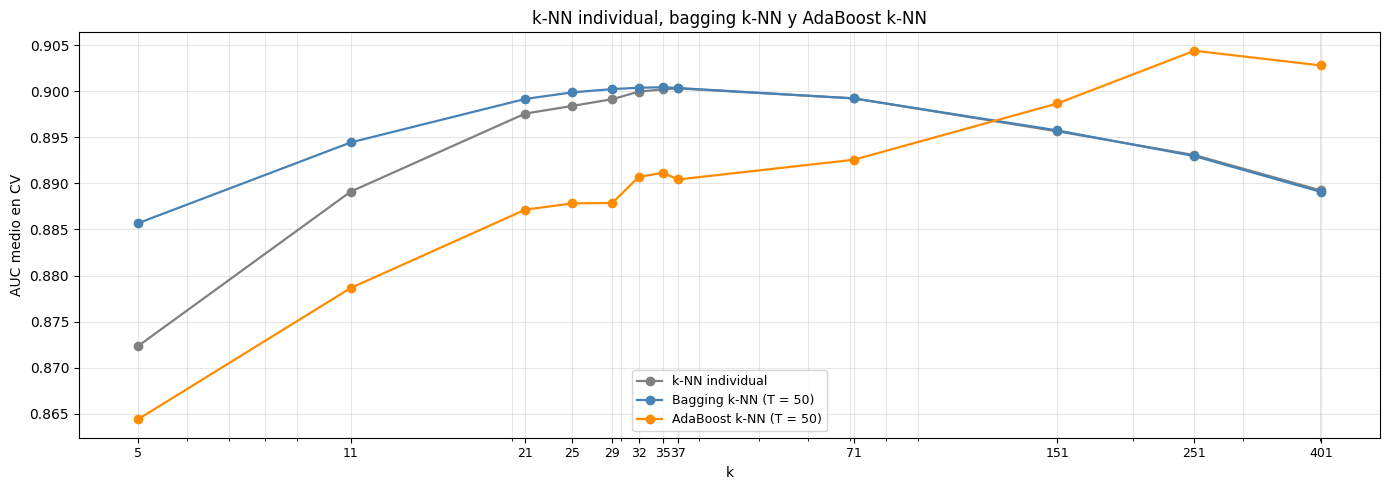

In [41]:
# Recuperar curva AUC del k-NN individual (reutiliza knn_grid si está en memoria)
if 'knn_grid' in globals():
    _best_w = knn_best_params['weights']
    _best_m = knn_best_params['metric']
    _knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
    _mask = ((_knn_cv_df['param_classifier__weights'] == _best_w) &
             (_knn_cv_df['param_classifier__metric']  == _best_m))
    knn_curve_exp1 = (
        _knn_cv_df.loc[_mask]
            .assign(n_neighbors=lambda d: d['param_classifier__n_neighbors'].astype(int))
            [['n_neighbors', 'mean_test_AUC']]
            .rename(columns={'mean_test_AUC': 'AUC_knn'})
            .sort_values('n_neighbors').reset_index(drop=True)
    )
else:
    print("knn_grid no disponible — recomputando curva k-NN individual para los 12 valores de k...")
    _knn_records = []
    for _k in k_values:
        _pipe = Pipeline([
            ('preprocessor', preprocessor_knn),
            ('classifier', KNeighborsClassifier(n_neighbors=_k, weights='distance', metric='manhattan'))
        ])
        _cv = cross_validate(_pipe, X_train, y_train, cv=cv,
                             scoring={'AUC': 'roc_auc'}, n_jobs=-1)
        _knn_records.append({'n_neighbors': _k, 'AUC_knn': float(np.mean(_cv['test_AUC']))})
        print(f"  k = {_k:>4}   AUC = {_knn_records[-1]['AUC_knn']:.6f}")
    knn_curve_exp1 = pd.DataFrame(_knn_records).sort_values('n_neighbors').reset_index(drop=True)

# Recuperar curva del bagging k-NN
if 'bagging_knn_results' not in globals():
    with open('bagging_knn_all_results.json') as f:
        bagging_knn_results = pd.DataFrame(json.load(f))
bag_curve_exp1 = bagging_knn_results.sort_values('n_neighbors')[['n_neighbors', 'AUC']].reset_index(drop=True)

# Curva AdaBoost k-NN (recién calculada)
ada_curve_exp1 = adaboost_knn_results.sort_values('n_neighbors')[['n_neighbors', 'AUC']].reset_index(drop=True)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(knn_curve_exp1['n_neighbors'], knn_curve_exp1['AUC_knn'],
        'o-', color='gray', markersize=6, linewidth=1.6, label='k-NN individual')
ax.plot(bag_curve_exp1['n_neighbors'], bag_curve_exp1['AUC'],
        'o-', color='steelblue', markersize=6, linewidth=1.6, label='Bagging k-NN (T = 50)')
ax.plot(ada_curve_exp1['n_neighbors'], ada_curve_exp1['AUC'],
        'o-', color='darkorange', markersize=6, linewidth=1.6,
        label='AdaBoost k-NN (T = 50)')

ax.set_xscale('log')
ax.set_xticks(k_values)
ax.set_xticklabels(k_values, fontsize=9)
ax.set_xlabel('k')
ax.set_ylabel('AUC medio en CV')
ax.set_title('k-NN individual, bagging k-NN y AdaBoost k-NN')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9, loc='lower center')
plt.tight_layout()
plt.savefig('Fotos/knn_vs_bagging_vs_adaboost_AUC_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2. Experimento 2: ¿Sobreajusta AdaBoost al aumentar el número de iteraciones?

Se entrena `AdaBoostClassifier` con *profundidad 1* (`max_depth=1`) como estimador base y se varía $T \in \{10, 25, 50, 100, 200, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000\}$. Para cada $T$ se registra el AUC medio en entrenamiento y en validación cruzada mediante `cross_validate(..., return_train_score=True)`, lo que permite visualizar si el error de test crece cuando el de entrenamiento sigue bajando.

In [43]:
n_estimators_range = [10, 25, 50, 100, 200, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000]
adaboost_tree_records = []

t0 = time.perf_counter()
for T in n_estimators_range:
    pipe = Pipeline([
        ('preprocessor', preprocessor_dt),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
            n_estimators=T,
            random_state=42
        ))
    ])
    cv_out = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    record = {
        'n_estimators': T,
        'AUC_train':    float(np.mean(cv_out['train_AUC'])),
        **{m: float(np.mean(cv_out[f'test_{m}'])) for m in scoring}
    }
    adaboost_tree_records.append(record)
    print(f"  T = {T:>5}   AUC_train = {record['AUC_train']:.6f}   AUC_cv = {record['AUC']:.6f}")
t1 = time.perf_counter()

adaboost_tree_results = pd.DataFrame(adaboost_tree_records)

# T óptimo según AUC en CV
best_idx_ada = adaboost_tree_results['AUC'].idxmax()
T_opt = int(adaboost_tree_results.loc[best_idx_ada, 'n_estimators'])
adaboost_tree_metrics = {m: float(adaboost_tree_results.loc[best_idx_ada, m]) for m in scoring}
adaboost_tree_best_params_val = {
    'n_estimators':   T_opt,
    'max_depth_base': 1
}

print(f"\n=== AdaBoost Árbol (decision stump) ===")
print(f"T óptimo (mejor AUC en CV): {T_opt}")
print(f"→ Tiempo total: {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) con T óptimo:")
for m, v in adaboost_tree_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

with open('adaboost_tree_best_params.json', 'w') as f:
    json.dump({'best_params': adaboost_tree_best_params_val,
               'cv_metrics':  {m: round(v, 4) for m, v in adaboost_tree_metrics.items()}},
              f, indent=4)
print("→ Hiperparámetros guardados en adaboost_tree_best_params.json")

  T =    10   AUC_train = 0.907889   AUC_cv = 0.903560
  T =    25   AUC_train = 0.918937   AUC_cv = 0.913373
  T =    50   AUC_train = 0.928606   AUC_cv = 0.922040
  T =   100   AUC_train = 0.936383   AUC_cv = 0.927106
  T =   200   AUC_train = 0.944297   AUC_cv = 0.933285
  T =   500   AUC_train = 0.959894   AUC_cv = 0.942042
  T =   750   AUC_train = 0.963535   AUC_cv = 0.943333
  T =  1000   AUC_train = 0.965033   AUC_cv = 0.944027
  T =  1500   AUC_train = 0.969537   AUC_cv = 0.945621
  T =  2000   AUC_train = 0.971997   AUC_cv = 0.946181
  T =  2500   AUC_train = 0.974609   AUC_cv = 0.946896
  T =  3000   AUC_train = 0.975955   AUC_cv = 0.947030
  T =  4000   AUC_train = 0.980081   AUC_cv = 0.948487
  T =  5000   AUC_train = 0.982496   AUC_cv = 0.948576

=== AdaBoost Árbol (decision stump) ===
T óptimo (mejor AUC en CV): 5000
→ Tiempo total: 828.5 s

Métricas medias (5-fold CV) con T óptimo:
  AUC           : 0.9486
  Exactitud     : 0.9330
  Tasa de error : 0.0670
  Precisión   

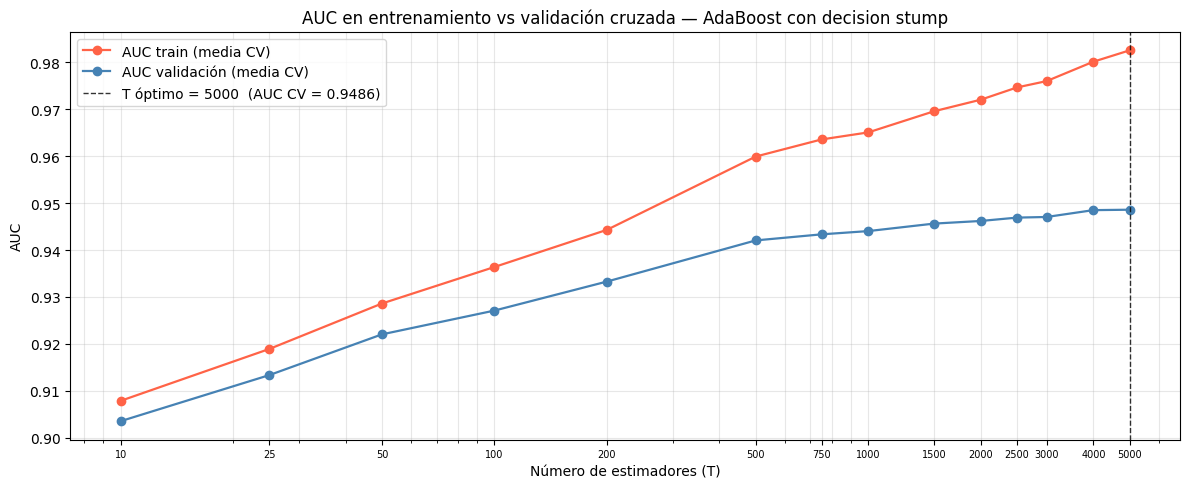

In [44]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(adaboost_tree_results['n_estimators'], adaboost_tree_results['AUC_train'],
        'o-', color='tomato', markersize=6, linewidth=1.6, label='AUC train (media CV)')
ax.plot(adaboost_tree_results['n_estimators'], adaboost_tree_results['AUC'],
        'o-', color='steelblue', markersize=6, linewidth=1.6, label='AUC validación (media CV)')

best_auc_cv_ada = float(adaboost_tree_results.loc[best_idx_ada, 'AUC'])
ax.axvline(T_opt, color='black', linestyle='--', linewidth=1.0, alpha=0.8,
           label=f'T óptimo = {T_opt}  (AUC CV = {best_auc_cv_ada:.4f})')

ax.set_xscale('log')
ax.set_xticks(n_estimators_range)
ax.set_xticklabels(n_estimators_range, fontsize=7)
ax.set_xlabel('Número de estimadores (T)')
ax.set_ylabel('AUC')
ax.set_title('AUC en entrenamiento vs validación cruzada — AdaBoost con decision stump')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('Fotos/adaboost_overfit_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3. Experimento 3: Comparativa final — Árbol vs AdaBoost vs Gradient Boosting

Se toma el árbol optimizado en la sección 4.3 como referencia, el AdaBoost con el $T^*$ del Experimento 2 y el Gradient Boosting con `GridSearchCV` sobre `n_estimators` $\in \{10, 25, 50, 100, 200, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000\}$ y`learning_rate` $\in \{0.01, 0.025, 0.05, 0.075, 0.1, 0.2, 0.3, 0.5, 1.0\}$.

In [36]:
# Gradient Boosting: GridSearchCV
gb_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', GradientBoostingClassifier(
        max_depth=3,
        random_state=42
    ))
])

gb_params = {
    'classifier__n_estimators':  [10, 25, 50, 100, 200, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000],
    'classifier__learning_rate': [0.01, 0.025, 0.05, 0.075, 0.1, 0.2, 0.3, 0.5, 1.0]
}

t0_gb = time.perf_counter()
gb_grid = GridSearchCV(
    gb_pipe, gb_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=-1, verbose=2
)
gb_grid.fit(X_train, y_train)
t1_gb = time.perf_counter()

gb_best_idx     = gb_grid.best_index_
gb_best_params_val = {k.replace('classifier__', ''): v for k, v in gb_grid.best_params_.items()}
gb_best_params_val['max_depth'] = 3
gb_metrics = {m: float(gb_grid.cv_results_[f'mean_test_{m}'][gb_best_idx]) for m in scoring}

print("=== Gradient Boosting ===")
print(f"Mejores hiperparámetros: {gb_best_params_val}")
print(f"\n→ Tiempo de entrenamiento (GridSearchCV): {t1_gb - t0_gb:.1f} s")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in gb_metrics.items():
    print(f"  {m:<14}: {v:.4f}")
print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

with open('gradient_boosting_best_params.json', 'w') as f:
    json.dump({'best_params': gb_best_params_val,
               'cv_metrics':  {m: round(v, 4) for m, v in gb_metrics.items()}},
              f, indent=4)
print("→ Hiperparámetros guardados en gradient_boosting_best_params.json")

Fitting 5 folds for each of 126 candidates, totalling 630 fits
=== Gradient Boosting ===
Mejores hiperparámetros: {'learning_rate': 0.075, 'n_estimators': 2500, 'max_depth': 3}

→ Tiempo de entrenamiento (GridSearchCV): 3221.9 s

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9518
  Exactitud     : 0.9353
  Tasa de error : 0.0647
  Precisión     : 0.9368
  Sensibilidad  : 0.7547
  Especificidad : 0.9858
  F1-Score      : 0.8359

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en gradient_boosting_best_params.json


In [45]:
# Recuperar métricas del árbol individual si no están en memoria
if 'dt_metrics' not in globals():
    with open('dt_best_params.json') as f:
        _dt_json = json.load(f)
    dt_metrics = _dt_json['cv_metrics']

# --- Árbol individual: reentrenar y medir tiempo ---
if 'dt_grid' in globals():
    _dt_best_pipe = dt_grid.best_estimator_
else:
    with open('dt_best_params.json') as f:
        _dt_p = json.load(f)['best_params']
    _dt_best_pipe = Pipeline([
        ('preprocessor', preprocessor_dt),
        ('classifier', DecisionTreeClassifier(
            criterion=_dt_p.get('criterion', 'gini'),
            max_depth=_dt_p.get('max_depth', None),
            min_samples_split=_dt_p.get('min_samples_split', 2),
            min_samples_leaf=_dt_p.get('min_samples_leaf', 1),
            class_weight=_dt_p.get('class_weight', None),
            random_state=42
        ))
    ])

t0_dt = time.perf_counter()
_dt_best_pipe.fit(X_train, y_train)
t1_dt = time.perf_counter()

# --- AdaBoost: reentrenar con T óptimo y medir tiempo ---
ada_final_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=T_opt,
        random_state=42
    ))
])
t0_ada = time.perf_counter()
ada_final_pipe.fit(X_train, y_train)
t1_ada = time.perf_counter()

# --- Gradient Boosting: reentrenar y medir tiempo ---
t0_gb2 = time.perf_counter()
gb_grid.best_estimator_.fit(X_train, y_train)
t1_gb2 = time.perf_counter()

# --- Tabla comparativa ---
boosting_summary = pd.DataFrame({
    'Árbol individual':          dt_metrics,
    f'AdaBoost (T={T_opt})':     adaboost_tree_metrics,
    'Gradient Boosting':         gb_metrics,
}).T.round(4)

print("=== Tabla comparativa — métricas medias en 5-fold CV ===")
display(boosting_summary)

print("\n=== Tiempos de reentrenamiento sobre X_train completo ===")
print(f"  Árbol individual   : {t1_dt  - t0_dt:.3f} s")
print(f"  AdaBoost: {t1_ada - t0_ada:.3f} s")
print(f"  Gradient Boosting  : {t1_gb2 - t0_gb2:.3f} s")

=== Tabla comparativa — métricas medias en 5-fold CV ===


,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Árbol individual,0.9168,0.8918,0.1082,0.7442,0.7687,0.9262,0.7562
AdaBoost (T=5000),0.9486,0.9330,0.0670,0.9321,0.7476,0.9848,0.8297
Gradient Boosting,0.9518,0.9353,0.0647,0.9368,0.7547,0.9858,0.8359



=== Tiempos de reentrenamiento sobre X_train completo ===
  Árbol individual   : 2.702 s
  AdaBoost: 190.958 s
  Gradient Boosting  : 88.668 s


### Conclusión de la Sección 6

Los resultados confirman las propiedades teóricas del *boosting*: AdaBoost reduce más el sesgo cuando $k$ es grande, el bagging reduce más la varianza cuando $k$ es pequeño, y el error de test de AdaBoost no colapsa al aumentar $T$ gracias al argumento del margen. En la comparativa final, el Gradient Boosting es el modelo más preciso en AUC mientras que el árbol individual destaca en sensibilidad; la elección dependerá del equilibrio entre rendimiento predictivo, coste computacional e interpretabilidad.

## 7. Voting y Stacking

### 7.1. Pipelines base

Se reconstruyen los cinco modelos óptimos como pipelines completos cargando los hiperparámetros desde los JSON de secciones anteriores (patrón de celda 63).

In [46]:
# Cargar pipelines óptimos (patrón de celda 63): globals() si están en memoria, JSON si no

# ─ Regresión Logística ─
if 'lr_pipe' in globals():
    _lr_base = lr_pipe
else:
    with open('lr_best_params.json') as _f: _p = json.load(_f)['best_params']
    _lr_base = Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(C=np.inf, solver=_p.get('solver', 'lbfgs'),
                                          max_iter=int(_p.get('max_iter', 2000)), random_state=42))
    ])

# ─ K-NN ─
if 'knn_grid' in globals():
    _knn_base = knn_grid.best_estimator_
else:
    with open('knn_best_params.json') as _f: _p = json.load(_f)['best_params']
    _knn_base = Pipeline([
        ('preprocessor', preprocessor_knn),
        ('classifier', KNeighborsClassifier(n_neighbors=int(_p['n_neighbors']),
                                            weights=_p['weights'], metric=_p['metric']))
    ])

# ─ Árbol de Clasificación ─
if 'dt_grid' in globals():
    _dt_base = dt_grid.best_estimator_
else:
    with open('dt_best_params.json') as _f: _p = json.load(_f)['best_params']
    _dt_base = Pipeline([
        ('preprocessor', preprocessor_dt),
        ('classifier', DecisionTreeClassifier(
            criterion=_p.get('criterion', 'gini'), max_depth=_p.get('max_depth'),
            min_samples_split=int(_p.get('min_samples_split', 2)),
            min_samples_leaf=int(_p.get('min_samples_leaf', 1)),
            class_weight=_p.get('class_weight'), random_state=42))
    ])

# ─ Random Forest ─
if 'rf_grid' in globals():
    _rf_base = rf_grid.best_estimator_
else:
    with open('rf_best_params.json') as _f: _p = json.load(_f)['best_params']
    _rf_base = Pipeline([
        ('preprocessor', preprocessor_dt),
        ('classifier', RandomForestClassifier(
            n_estimators=int(_p.get('n_estimators', 500)),
            max_features=_p.get('max_features', 'sqrt'),
            max_depth=None, min_samples_leaf=1, min_samples_split=2,
            bootstrap=True, class_weight='balanced', random_state=42))
    ])

# ─ Gradient Boosting ─
if 'gb_grid' in globals():
    _gb_base = gb_grid.best_estimator_
else:
    with open('gradient_boosting_best_params.json') as _f: _p = json.load(_f)['best_params']
    _gb_base = Pipeline([
        ('preprocessor', preprocessor_dt),
        ('classifier', GradientBoostingClassifier(
            n_estimators=int(_p.get('n_estimators', 2500)),
            learning_rate=float(_p.get('learning_rate', 0.075)),
            max_depth=int(_p.get('max_depth', 3)), random_state=42))
    ])

_base_estimators = [
    ('lr',  _lr_base), ('knn', _knn_base), ('dt', _dt_base),
    ('rf',  _rf_base), ('gb',  _gb_base),
]
print('Pipelines base construidos:')
for _n, _ in _base_estimators:
    print(f'  · {_n}')


Pipelines base construidos:
  · lr
  · knn
  · dt
  · rf
  · gb


### 7.2. Hard Voting, Soft Voting y Stacking

Evaluación con `cross_validate` (5 folds, mismo `cv` y `scoring` del notebook) y medición del tiempo de reentrenamiento sobre `X_train` completo.
El Voting hard no dispone de `predict_proba`; su AUC se registra como `null`.

In [47]:
# Scoring sin AUC para Voting hard (no tiene predict_proba)
_scoring_no_auc = {k: v for k, v in scoring.items() if k != 'AUC'}

# ─── Voting hard ──────────────────────────────────────────────────────────────
voting_hard = VotingClassifier(estimators=_base_estimators, voting='hard')

_cv_vh = cross_validate(voting_hard, X_train, y_train, cv=cv, scoring=_scoring_no_auc, n_jobs=-1)
vh_metrics = {m: float(np.mean(_cv_vh[f'test_{m}'])) for m in _scoring_no_auc}
vh_metrics['AUC'] = float('nan')

t0 = time.perf_counter(); voting_hard.fit(X_train, y_train); _vh_time = time.perf_counter() - t0

print(f'=== Voting hard  (fit X_train: {_vh_time:.2f} s) ===')
for m, v in vh_metrics.items():
    print(f'  {m:<14}: {"N/A" if (isinstance(v, float) and np.isnan(v)) else f"{v:.4f}"}')

# ─── Voting soft ──────────────────────────────────────────────────────────────
voting_soft = VotingClassifier(estimators=_base_estimators, voting='soft')

_cv_vs = cross_validate(voting_soft, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
vs_metrics = {m: float(np.mean(_cv_vs[f'test_{m}'])) for m in scoring}

t0 = time.perf_counter(); voting_soft.fit(X_train, y_train); _vs_time = time.perf_counter() - t0

print(f'\n=== Voting soft  (fit X_train: {_vs_time:.2f} s) ===')
for m, v in vs_metrics.items():
    print(f'  {m:<14}: {v:.4f}')

# ─── Stacking ─────────────────────────────────────────────────────────────────
# n_jobs=1 en cross_validate para evitar paralelismo anidado con el cv=5 interno del Stacking
stacking_clf = StackingClassifier(
    estimators=_base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    stack_method='predict_proba',
    cv=5
)

_cv_st = cross_validate(stacking_clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
st_metrics = {m: float(np.mean(_cv_st[f'test_{m}'])) for m in scoring}

t0 = time.perf_counter(); stacking_clf.fit(X_train, y_train); _st_time = time.perf_counter() - t0

print(f'\n=== Stacking  (fit X_train: {_st_time:.2f} s) ===')
for m, v in st_metrics.items():
    print(f'  {m:<14}: {v:.4f}')

# ─── Tabla comparativa ────────────────────────────────────────────────────────
ensemble_s7 = pd.DataFrame({
    'Voting hard': vh_metrics,
    'Voting soft': vs_metrics,
    'Stacking':    st_metrics,
}).T.round(4)

print('\n=== Tabla comparativa — métricas medias en 5-fold CV ===')
display(ensemble_s7)
print(f'\nTiempos de reentrenamiento sobre X_train completo:')
print(f'  Voting hard : {_vh_time:.3f} s')
print(f'  Voting soft : {_vs_time:.3f} s')
print(f'  Stacking    : {_st_time:.3f} s')

# ─── Guardar JSONs ────────────────────────────────────────────────────────────
with open('voting_hard_results.json', 'w') as _f:
    json.dump({'best_params': {'voting': 'hard'},
               'cv_metrics':  {m: (None if (isinstance(v, float) and np.isnan(v)) else round(v, 4))
                                for m, v in vh_metrics.items()},
               'train_time_s': round(_vh_time, 3)}, _f, indent=4)

with open('voting_soft_results.json', 'w') as _f:
    json.dump({'best_params': {'voting': 'soft'},
               'cv_metrics':  {m: round(v, 4) for m, v in vs_metrics.items()},
               'train_time_s': round(_vs_time, 3)}, _f, indent=4)

with open('stacking_results.json', 'w') as _f:
    json.dump({'best_params': {'final_estimator': 'LogisticRegression',
                               'final_estimator_max_iter': 1000,
                               'stack_method': 'predict_proba', 'cv': 5},
               'cv_metrics':  {m: round(v, 4) for m, v in st_metrics.items()},
               'train_time_s': round(_st_time, 3)}, _f, indent=4)

print('\n→ Resultados guardados en voting_hard_results.json, voting_soft_results.json, stacking_results.json')


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


=== Voting hard  (fit X_train: 160.45 s) ===
  Exactitud     : 0.9325
  Tasa de error : 0.0675
  Precisión     : 0.9547
  Sensibilidad  : 0.7253
  Especificidad : 0.9904
  F1-Score      : 0.8243
  AUC           : N/A


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



=== Voting soft  (fit X_train: 137.79 s) ===
  AUC           : 0.9389
  Exactitud     : 0.9336
  Tasa de error : 0.0664
  Precisión     : 0.9573
  Sensibilidad  : 0.7283
  Especificidad : 0.9909
  F1-Score      : 0.8272


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C a


=== Stacking  (fit X_train: 1037.83 s) ===
  AUC           : 0.9506
  Exactitud     : 0.9370
  Tasa de error : 0.0630
  Precisión     : 0.9451
  Sensibilidad  : 0.7554
  Especificidad : 0.9877
  F1-Score      : 0.8396

=== Tabla comparativa — métricas medias en 5-fold CV ===


,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score,AUC
Voting hard,0.9325,0.0675,0.9547,0.7253,0.9904,0.8243,NaN
Voting soft,0.9336,0.0664,0.9573,0.7283,0.9909,0.8272,0.9389
Stacking,0.9370,0.0630,0.9451,0.7554,0.9877,0.8396,0.9506



Tiempos de reentrenamiento sobre X_train completo:
  Voting hard : 160.451 s
  Voting soft : 137.786 s
  Stacking    : 1037.829 s

→ Resultados guardados en voting_hard_results.json, voting_soft_results.json, stacking_results.json


In [53]:
# ──────────────────────────────────────────────────────────────────────────────
# 7.3. Diagnóstico interno: acuerdo del hard voting y pesos del meta-modelo
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict

_names  = [n for n, _ in _base_estimators]                       # ['lr','knn','dt','rf','gb']
_pretty = {'lr': 'Regresión Logística', 'knn': 'k-NN', 'dt': 'Árbol',
           'rf': 'Random Forest', 'gb': 'Gradient Boosting'}

# ═══════════════════════════════════════════════════════════════════════════════
# (A) MATRIZ DE ACUERDO DEL HARD VOTING
#     Votos de clase fuera de muestra (mismo cv de 5 folds). El voto de cada modelo
#     es la clase predicha (predict_proba >= 0.5), idéntico al hard voting de sklearn.
#     Nota: puede tardar un par de minutos por el Gradient Boosting.
# ═══════════════════════════════════════════════════════════════════════════════
_votes = {}
for _n, _est in _base_estimators:
    _p = cross_val_predict(_est, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    _votes[_n] = (_p >= 0.5).astype(int)

_votes = pd.DataFrame(_votes, index=X_train.index)

print('='*72)
print('(A) HARD VOTING — matriz de acuerdo por pares (5-fold CV)')
print('='*72)
print('\nProporción de observaciones en que cada par de modelos emite el mismo voto:')
_agree = pd.DataFrame({_pretty[a]: {_pretty[b]: (_votes[a] == _votes[b]).mean()
                                    for b in _names} for a in _names})
display(_agree.round(4))

# Acuerdo medio entre pares distintos (sin contar la diagonal de unos)
_mask = ~np.eye(len(_names), dtype=bool)
print(f'Acuerdo medio entre pares distintos: {_agree.values[_mask].mean():.4f}')

# ═══════════════════════════════════════════════════════════════════════════════
# (B) COEFICIENTES del meta-modelo del stacking (regresión logística)  —  SIEMPRE
#     En binario con stack_method='predict_proba', sklearn pasa al meta-modelo
#     SOLO la probabilidad de la clase positiva de cada modelo base
#     → un coeficiente por modelo base.
# ═══════════════════════════════════════════════════════════════════════════════
if 'stacking_clf' not in globals() or not hasattr(stacking_clf, 'final_estimator_'):
    stacking_clf = StackingClassifier(
        estimators=_base_estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        stack_method='predict_proba', cv=5).fit(X_train, y_train)

_meta      = stacking_clf.final_estimator_
_coef      = _meta.coef_.ravel()
_intercept = float(_meta.intercept_[0])

print('\n' + '='*72)
print('(B) STACKING — coeficientes del meta-modelo (regresión logística)')
print('='*72)
print(f'\nIntercepto (β0): {_intercept:.4f}\n')
_coef_tbl = pd.DataFrame({
    'Coeficiente': {_pretty[n]: _coef[i] for i, n in enumerate(_names)},
    'Peso relativo (|coef| norm.)': {_pretty[n]: abs(_coef[i]) / np.abs(_coef).sum()
                                     for i, n in enumerate(_names)},
})
display(_coef_tbl.round(4))

(A) HARD VOTING — matriz de acuerdo por pares (5-fold CV)

Proporción de observaciones en que cada par de modelos emite el mismo voto:


,Regresión Logística,k-NN,Árbol,Random Forest,Gradient Boosting
Regresión Logística,1.0000,0.9248,0.8802,0.9086,0.9049
k-NN,0.9248,1.0000,0.8956,0.9511,0.9397
Árbol,0.8802,0.8956,1.0000,0.9270,0.9221
Random Forest,0.9086,0.9511,0.9270,1.0000,0.9756
Gradient Boosting,0.9049,0.9397,0.9221,0.9756,1.0000


Acuerdo medio entre pares distintos: 0.9230

(B) STACKING — coeficientes del meta-modelo (regresión logística)

Intercepto (β0): -3.6274



,Coeficiente,Peso relativo (|coef| norm.)
Regresión Logística,-0.3289,0.0358
k-NN,0.0484,0.0053
Árbol,0.4273,0.0465
Random Forest,4.1044,0.4471
Gradient Boosting,4.2711,0.4653


## 8. Comparativa final y evaluación en Test

### 8.1. Tabla comparativa

Métricas medias en 5-fold CV cargadas desde los JSON guardados en disco. El tiempo de entrenamiento se mide reentrenando cada modelo una vez sobre `X_train` completo (para voting y stacking se reutiliza el tiempo ya guardado en su JSON si existe).

In [54]:
# ─── Cargar métricas desde disco ─────────────────────────────────────────────
_json_files_s8 = {
    'Regresión Logística':    'lr_best_params.json',
    'k-NN':                   'knn_best_params.json',
    'Árbol de Clasificación': 'dt_best_params.json',
    'Bagging de Árboles':     'bagging_tree_best_params.json',
    'Random Forest':          'rf_best_params.json',
    'AdaBoost':               'adaboost_tree_best_params.json',
    'Gradient Boosting':      'gradient_boosting_best_params.json',
    'Hard Voting':            'voting_hard_results.json',
    'Soft Voting':            'voting_soft_results.json',
    'Stacking':               'stacking_results.json',
}
_all_cv_s8 = {}
for _nm, _fn in _json_files_s8.items():
    with open(_fn) as _f:
        _all_cv_s8[_nm] = json.load(_f)['cv_metrics']

_model_names_s8 = [
    'Regresión Logística', 'k-NN', 'Árbol de Clasificación',
    'Bagging de Árboles', 'Random Forest', 'AdaBoost', 'Gradient Boosting',
    'Hard Voting', 'Soft Voting', 'Stacking'
]

# ─── Construir pipelines (patrón de celda 63) ────────────────────────────────
def _load_p(fname):
    with open(fname) as _f: return json.load(_f)['best_params']

_lrp  = _load_p('lr_best_params.json')
_knnp = _load_p('knn_best_params.json')
_dtp  = _load_p('dt_best_params.json')
_btp  = _load_p('bagging_tree_best_params.json')
_rfp  = _load_p('rf_best_params.json')
_adap = _load_p('adaboost_tree_best_params.json')
_gbp  = _load_p('gradient_boosting_best_params.json')

_bep_s8 = [
    ('lr',  Pipeline([('preprocessor', preprocessor_lr),
                      ('classifier', LogisticRegression(C=np.inf,
                          solver=_lrp.get('solver', 'lbfgs'),
                          max_iter=int(_lrp.get('max_iter', 2000)), random_state=42))])),
    ('knn', Pipeline([('preprocessor', preprocessor_knn),
                      ('classifier', KNeighborsClassifier(
                          n_neighbors=int(_knnp['n_neighbors']),
                          weights=_knnp['weights'], metric=_knnp['metric']))])),
    ('dt',  Pipeline([('preprocessor', preprocessor_dt),
                      ('classifier', DecisionTreeClassifier(
                          criterion=_dtp.get('criterion', 'gini'),
                          max_depth=_dtp.get('max_depth'),
                          min_samples_split=int(_dtp.get('min_samples_split', 2)),
                          min_samples_leaf=int(_dtp.get('min_samples_leaf', 1)),
                          class_weight=_dtp.get('class_weight'), random_state=42))])),
    ('rf',  Pipeline([('preprocessor', preprocessor_dt),
                      ('classifier', RandomForestClassifier(
                          n_estimators=int(_rfp.get('n_estimators', 500)),
                          max_features=_rfp.get('max_features', 'sqrt'),
                          max_depth=None, min_samples_leaf=1, min_samples_split=2,
                          bootstrap=True, class_weight='balanced', random_state=42))])),
    ('gb',  Pipeline([('preprocessor', preprocessor_dt),
                      ('classifier', GradientBoostingClassifier(
                          n_estimators=int(_gbp.get('n_estimators', 2500)),
                          learning_rate=float(_gbp.get('learning_rate', 0.075)),
                          max_depth=int(_gbp.get('max_depth', 3)), random_state=42))])),
]

_s8_pipes = {
    'Regresión Logística':    _bep_s8[0][1],
    'k-NN':                   _bep_s8[1][1],
    'Árbol de Clasificación': _bep_s8[2][1],
    'Bagging de Árboles': Pipeline([('preprocessor', preprocessor_dt),
                                    ('classifier', BaggingClassifier(
                                        estimator=DecisionTreeClassifier(
                                            max_depth=None, min_samples_leaf=1,
                                            min_samples_split=2, class_weight='balanced',
                                            random_state=42),
                                        n_estimators=int(_btp.get('n_estimators', 500)),
                                        bootstrap=bool(_btp.get('bootstrap', True)),
                                        random_state=42))]),
    'Random Forest':          _bep_s8[3][1],
    'AdaBoost': Pipeline([('preprocessor', preprocessor_dt),
                           ('classifier', AdaBoostClassifier(
                               estimator=DecisionTreeClassifier(
                                   max_depth=int(_adap.get('max_depth_base', 1)),
                                   random_state=42),
                               n_estimators=int(_adap.get('n_estimators', 5000)),
                               random_state=42))]),
    'Gradient Boosting':      _bep_s8[4][1],
    'Hard Voting': VotingClassifier(estimators=_bep_s8, voting='hard'),
    'Soft Voting': VotingClassifier(estimators=_bep_s8, voting='soft'),
    'Stacking': StackingClassifier(
        estimators=_bep_s8,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        stack_method='predict_proba', cv=5),
}

# ─── Medir tiempos de entrenamiento ──────────────────────────────────────────
_train_times_s8 = {}

# Reusar tiempos ya guardados en la sección 7
for _nm, _fn in [('Hard Voting', 'voting_hard_results.json'),
                 ('Soft Voting', 'voting_soft_results.json'),
                 ('Stacking',    'stacking_results.json')]:
    try:
        with open(_fn) as _f: _t = json.load(_f).get('train_time_s')
        if _t is not None: _train_times_s8[_nm] = _t
    except FileNotFoundError:
        pass

print('Midiendo tiempos de entrenamiento sobre X_train...')
for _nm in _model_names_s8:
    if _nm in _train_times_s8:
        print(f'  {_nm:<28}: {_train_times_s8[_nm]:.3f} s  (cargado de JSON)')
        continue
    _t0 = time.perf_counter()
    _s8_pipes[_nm].fit(X_train, y_train)
    _train_times_s8[_nm] = round(time.perf_counter() - _t0, 3)
    print(f'  {_nm:<28}: {_train_times_s8[_nm]:.3f} s')

# ─── Tabla comparativa ────────────────────────────────────────────────────────
_rows_s8 = []
for _nm in _model_names_s8:
    _m = _all_cv_s8[_nm]
    _rows_s8.append({
        'Modelo':        _nm,
        'AUC':           _m.get('AUC'),
        'Exactitud':     _m.get('Exactitud'),
        'Tasa de error': _m.get('Tasa de error'),
        'Precisión':     _m.get('Precisión'),
        'Sensibilidad':  _m.get('Sensibilidad'),
        'Especificidad': _m.get('Especificidad'),
        'F1-Score':      _m.get('F1-Score'),
        'Tiempo (s)':    _train_times_s8.get(_nm),
    })

comparativa_df = (pd.DataFrame(_rows_s8)
                    .set_index('Modelo')
                    .sort_values('AUC', ascending=False, na_position='last')
                    .round(4))
display(comparativa_df)

comparativa_df.to_csv('comparativa_final.csv')
print('\n→ Tabla guardada en comparativa_final.csv')


Midiendo tiempos de entrenamiento sobre X_train...


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


  Regresión Logística         : 4.234 s
  k-NN                        : 2.792 s
  Árbol de Clasificación      : 2.995 s
  Bagging de Árboles          : 75.577 s
  Random Forest               : 52.597 s
  AdaBoost                    : 321.555 s
  Gradient Boosting           : 210.932 s
  Hard Voting                 : 160.451 s  (cargado de JSON)
  Soft Voting                 : 137.786 s  (cargado de JSON)
  Stacking                    : 1037.829 s  (cargado de JSON)


,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score,Tiempo (s)
Modelo,,,,,,,,
Gradient Boosting,0.9518,0.9353,0.0647,0.9368,0.7547,0.9858,0.8359,210.932
Stacking,0.9506,0.9370,0.0630,0.9451,0.7554,0.9877,0.8396,1037.829
AdaBoost,0.9486,0.9330,0.0670,0.9321,0.7476,0.9848,0.8297,321.555
Soft Voting,0.9389,0.9336,0.0664,0.9573,0.7283,0.9909,0.8272,137.786
Random Forest,0.9384,0.9336,0.0664,0.9727,0.7160,0.9944,0.8248,52.597
Bagging de Árboles,0.9369,0.9325,0.0675,0.9661,0.7160,0.9930,0.8224,75.577
Árbol de Clasificación,0.9168,0.8918,0.1082,0.7442,0.7687,0.9262,0.7562,2.995
k-NN,0.9003,0.8962,0.1038,0.9207,0.5733,0.9863,0.7066,2.792
Regresión Logística,0.8711,0.8666,0.1334,0.7649,0.5612,0.9518,0.6474,4.234



→ Tabla guardada en comparativa_final.csv


### 8.2. Gráfico 1 — AUC barras horizontales

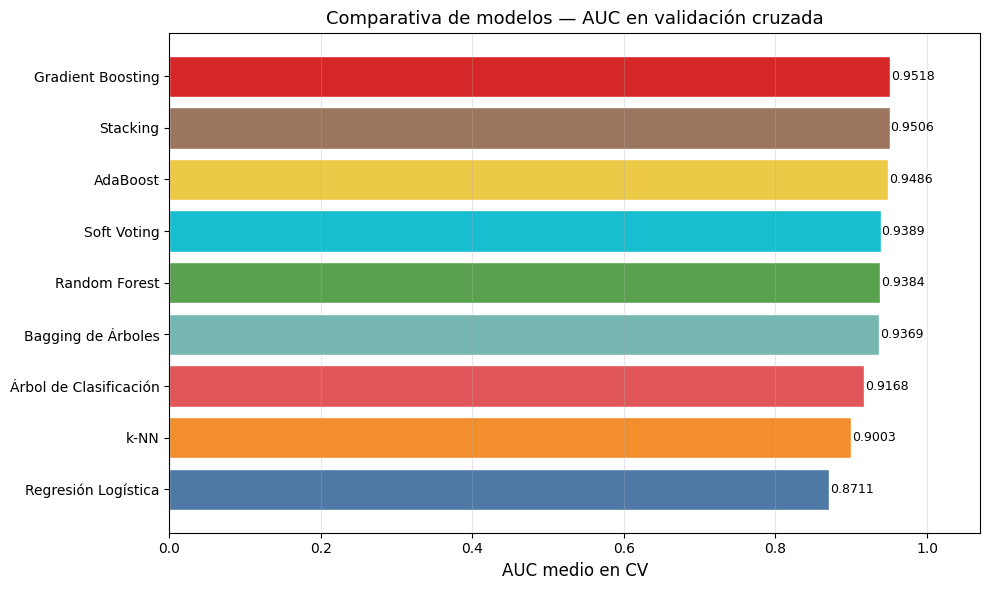

→ Guardado en Fotos/comparativa_auc.png


In [55]:
# Paleta de colores consistente para los dos gráficos
_MODEL_COLORS = {
    'Regresión Logística':    '#4e79a7',
    'k-NN':                   '#f28e2b',
    'Árbol de Clasificación': '#e15759',
    'Bagging de Árboles':     '#76b7b2',
    'Random Forest':          '#59a14f',
    'AdaBoost':               '#edc948',
    'Gradient Boosting':      '#b07aa1',
    'Hard Voting':            '#e377c2',
    'Soft Voting':            '#17becf',
    'Stacking':               '#9c755f',
}

_auc_series = comparativa_df['AUC'].dropna().sort_values()
_best_auc_model = _auc_series.idxmax()
_bar_colors = [('#d62728' if m == _best_auc_model else _MODEL_COLORS.get(m, '#888'))
               for m in _auc_series.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(_auc_series.index, _auc_series.values, color=_bar_colors, edgecolor='white')
for bar, val in zip(bars, _auc_series.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('AUC medio en CV', fontsize=12)
ax.set_title('Comparativa de modelos — AUC en validación cruzada', fontsize=13)
ax.set_xlim(0, 1.07)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Fotos/comparativa_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Guardado en Fotos/comparativa_auc.png')


### 8.3. Gráfico 2 — Curvas ROC en validación cruzada

Se obtienen probabilidades OOF mediante `cross_val_predict` (5 folds) para trazar la curva ROC de cada modelo. El **Hard Voting** no dispone de `predict_proba` y se excluye de este gráfico.

c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C a

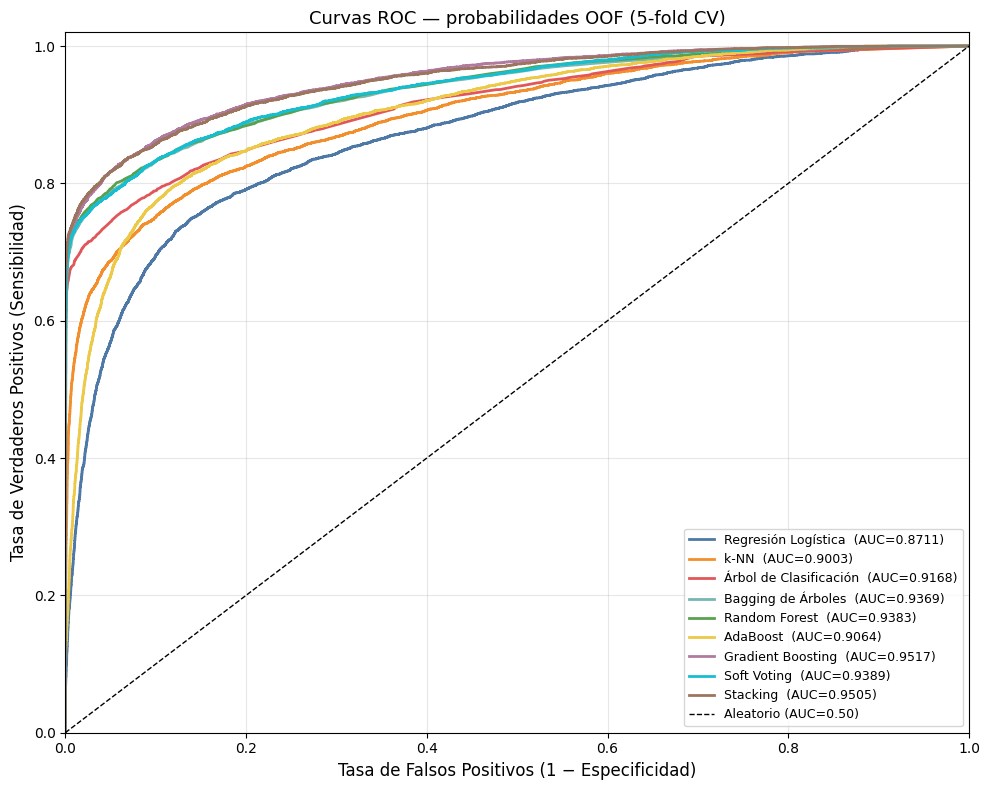

→ Guardado en Fotos/comparativa_roc.png


In [56]:
from sklearn.model_selection import cross_val_predict

_models_roc = [m for m in _model_names_s8 if m != 'Hard Voting']

fig, ax = plt.subplots(figsize=(10, 8))

for _nm in _models_roc:
    # cross_val_predict clona y reajusta internamente; n_jobs=1 para Stacking (paralelismo anidado)
    _n_jobs_roc = 1 if _nm == 'Stacking' else -1
    _y_oof = cross_val_predict(_s8_pipes[_nm], X_train, y_train,
                                cv=cv, method='predict_proba',
                                n_jobs=_n_jobs_roc)[:, 1]
    _fpr, _tpr, _ = roc_curve(y_train, _y_oof)
    _auc_val = roc_auc_score(y_train, _y_oof)
    ax.plot(_fpr, _tpr, color=_MODEL_COLORS.get(_nm, '#888'), lw=2,
            label=f'{_nm}  (AUC={_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax.set_title('Curvas ROC — probabilidades OOF (5-fold CV)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Fotos/comparativa_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Guardado en Fotos/comparativa_roc.png')
